In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [2]:
IMAGE_SIZE=256
BATCH_SIZE=32
CHANELS=3
EPOCS=50

In [3]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
  "../Training/PlantVillage",
  shuffle=True,
  image_size=(IMAGE_SIZE,IMAGE_SIZE),
  batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [4]:
class_name=dataset.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset)

68

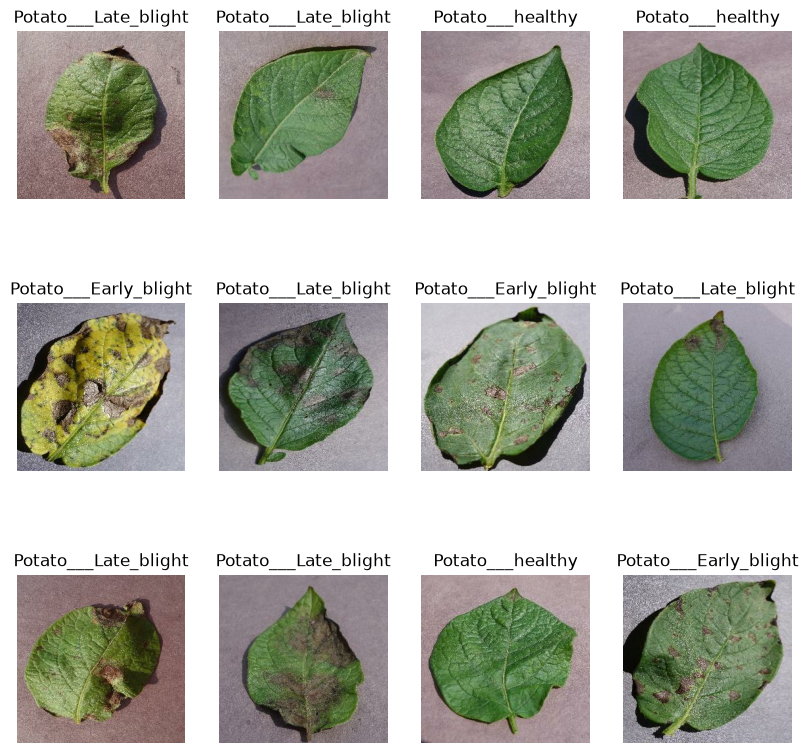

In [6]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
  for i in range(12):
   ax=plt.subplot(3,4,i+1)
   plt.imshow(image_batch[i].numpy().astype("uint8"))
   plt.title(class_name[label_batch[i]])
   plt.axis("off")

In [7]:
len(dataset)

68

In [8]:
train_size=0.8
len(dataset)*train_size
dataset.take(10)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [9]:
train_ds=dataset.take(54)
len(train_ds)

54

In [10]:
test_ds=dataset.skip(54)
len(test_ds)

14

In [11]:
val_size=0.1
len(dataset)*val_size

6.800000000000001

In [12]:
val_ds=test_ds.take(6)
len(val_ds)

6

In [13]:
test_ds=test_ds.skip(6)
len(test_ds)

8

In [14]:
def get_dataset_partitions_tf(
    ds,
    train_split=0.8,
    val_split=0.1,
    test_split=0.1,
    shuffle=True,
    shuffle_size=10000,
):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size)  # Takes all remaining elements

    return train_ds, val_ds, test_ds

In [15]:
train_ds,val_ds,test_ds=get_dataset_partitions_tf(dataset)

In [16]:
len(train_ds)

54

In [17]:
len(val_ds)

6

In [18]:
len(test_ds)

8

In [19]:
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [20]:
resize_and_rescale = tf.keras.Sequential(
    [
        tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
        tf.keras.layers.Rescaling(1.0 / 255),
    ]
)

In [21]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
    ]
)

In [25]:
n_classes=3
model=models.Sequential([
  resize_and_rescale,
  data_augmentation,
  layers.Conv2D(32,(3,3),activation='relu',input_shape=(IMAGE_SIZE,IMAGE_SIZE)),
  layers.MaxPooling2D((2,2)),
  layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),
  layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),
  layers.Conv2D(64,(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),
  layers.Conv2D(64,(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),
  layers.Conv2D(64,(3,3),activation='relu'),
  layers.MaxPooling2D((2,2)),
  layers.Flatten(),
  layers.Dense(64,activation='relu'),
  layers.Dense(n_classes,activation='softmax'),
])

model.build(input_shape=(BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANELS))

In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
  metrics=['accuracy']
)

In [28]:
history=model.fit(
  train_ds,
  epochs=EPOCS,
  batch_size=BATCH_SIZE,
  verbose=1,
  validation_data=val_ds
)

Epoch 1/50


c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


54/54 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5029 - loss: 0.8957 - val_accuracy: 0.5312 - val_loss: 0.8174
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6968 - loss: 0.6430 - val_accuracy: 0.8125 - val_loss: 0.4439
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.8177 - loss: 0.4307 - val_accuracy: 0.8646 - val_loss: 0.3169
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8328 - loss: 0.3969 - val_accuracy: 0.9062 - val_loss: 0.2393
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8571 - loss: 0.3447 - val_accuracy: 0.8177 - val_loss: 0.3731
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.8860 - loss: 0.2717 - val_accuracy: 0.9062 - val_loss: 0.2752
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.9172 - loss: 0.2189 - val_accuracy: 0.8958 - val_loss: 0.2367
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.9196 - loss: 0.2179 - val_accuracy: 0.9427 - val_loss: 0.1628
Epo

In [29]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - accuracy: 0.9961 - loss: 0.0142


In [30]:
scores

[0.014166743494570255, 0.99609375]

In [31]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [32]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [33]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

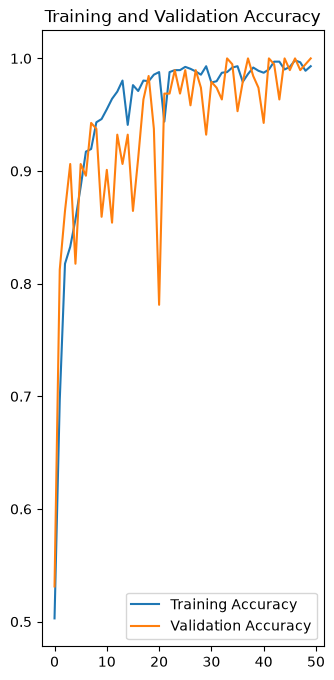

In [34]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCS),acc,label='Training Accuracy')
plt.plot(range(EPOCS),val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

first image to predict
first images actual label is Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
predicted labe:  Potato___Late_blight


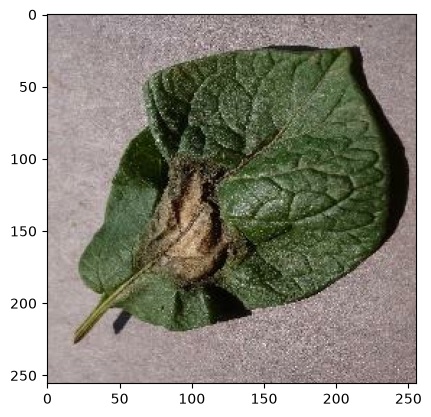

In [36]:
import numpy as np
for image_batch,label_batch in test_ds.take(1):
  first_image=image_batch[0].numpy().astype("uint8")
  first_label=label_batch[0]

  print("first image to predict")
  plt.imshow(first_image)
  print("first images actual label is",class_name[first_label])

  batch_prediction=model.predict(image_batch)
  print("predicted labe: ",class_name[np.argmax(batch_prediction[0])])

In [41]:
import tensorflow as tf
import numpy as np

def predict(model, img):
    # 1. Convert input image array to float32 tensor
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    
    # 2. Add batch dimension: shape becomes (1, height, width, channels)
    img_array = tf.expand_dims(img_array, 0)
    
    # 3. Predict
    predictions = model.predict(img_array, verbose=0)
    
    # 4. Extract class name and confidence score
    predicted_class = class_name[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    
    return predicted_class, confidence

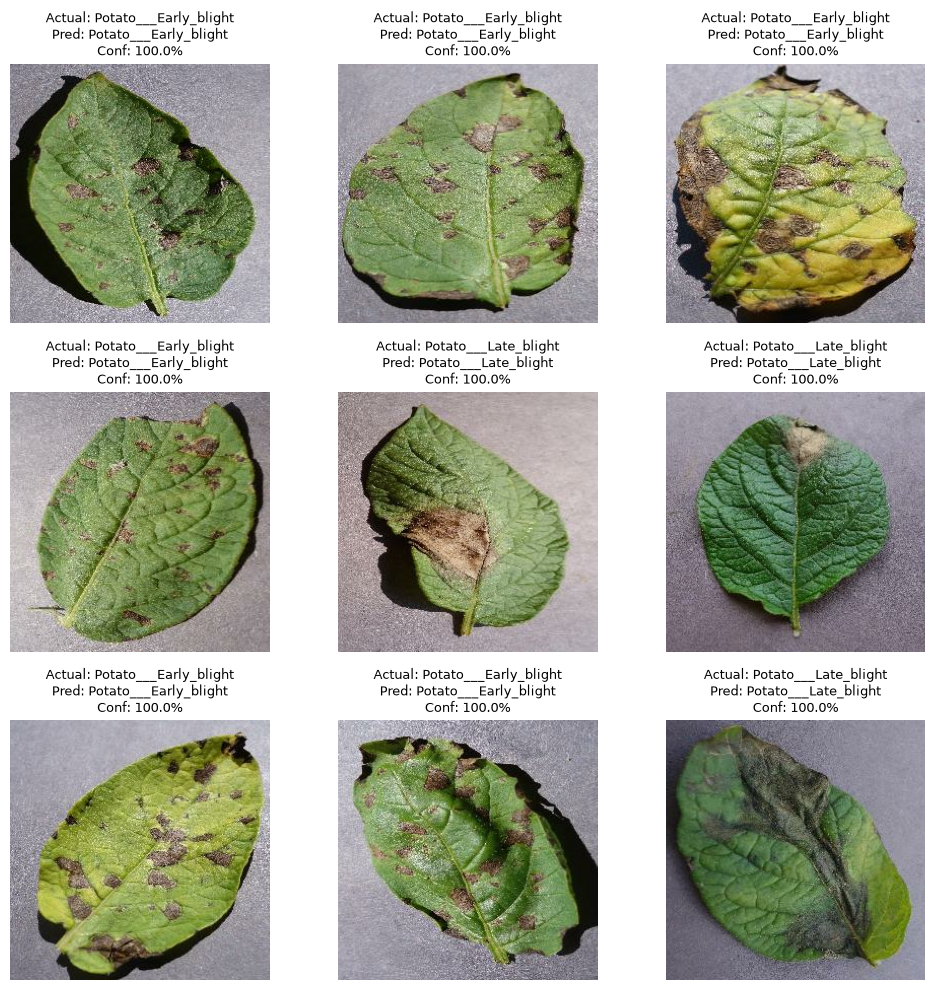

In [42]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # Display image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Model prediction (pass images[i].numpy() directly)
        predicted_class, confidence = predict(model, images[i].numpy())

        # Ground truth label
        label_idx = int(labels[i].numpy()) if hasattr(labels[i], "numpy") else int(labels[i])
        actual_class = class_name[label_idx]

        plt.title(f"Actual: {actual_class}\nPred: {predicted_class}\nConf: {confidence}%", fontsize=9)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
model_version = "1.0.0"
model.save(f"../Model/potato_disease_model_v{model_version}.h5")